In [2]:
import torchmetrics.segmentation
from torch.xpu import device

from DatasetLoading import RepairDatasetLoader
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import lightning as L
import torch
from lightning.pytorch.loggers import WandbLogger
import os

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from GridReconstruction import GridReconstructionNetwork
from GridReconstruction import GridReconstruction
from NerfRepresentationUtils import plot_colored_voxels
from NerfRepresentationUtils import plot_opacity_tensor
import torch.nn.functional as F

torch.set_float32_matmul_precision('medium')

from copy import copy

In [3]:
dataset_loader = RepairDatasetLoader(batch_size=2, dataset_type="FixedGridDataset",
                                         representation_folder_name="gridswithRepresentation", num_workers=2)

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
lightning_model = GridReconstruction.load_from_checkpoint("epoch_4.ckpt")
model = lightning_model.model
model.eval()
model.to(device)

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0
/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


GridReconstructionNetwork(
  (encoder): Sequential(
    (0): Conv3d(32, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(13, 13, 13))
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv3d(128, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (8): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (12): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (1

In [6]:
test_dataset = dataset_loader.test_dataloader().dataset

In [7]:
representation, idx_tensors, colour_tensor, directions = test_dataset.get_testing_items(2)

In [8]:
test_dataset.piece_names[2]

'RPf_00206.npz'

In [9]:
representation.shape

torch.Size([32, 200, 200, 200])

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

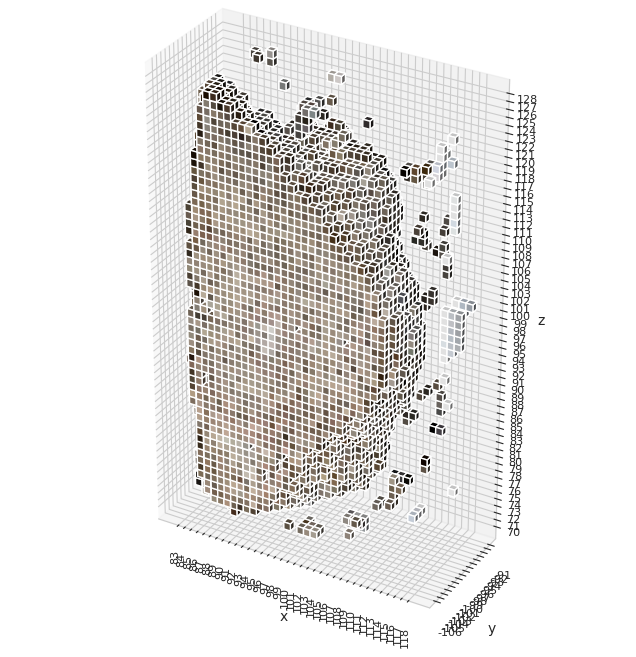

In [9]:
plot_colored_voxels(idx_tensors, colour_tensor)

In [10]:
with torch.no_grad():
    reconstructed_grid = model(representation.unsqueeze(0).to(device)).squeeze(0).cpu()

In [11]:
weights = reconstructed_grid[-1]

In [12]:
weights.shape

torch.Size([200, 200, 200])

In [13]:
r_idx_tensors = torch.where(weights > 0.3)

In [14]:
r_idx_tensors[0].shape[0]

0

In [15]:
random_directions = F.normalize(torch.randn((r_idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent = reconstructed_grid[:-1, r_idx_tensors[0], r_idx_tensors[1], r_idx_tensors[2]].T
r_colours = test_dataset.latent2representation.get_colour_from_latent(latent, random_directions).detach()


In [16]:
random_directions2 = F.normalize(torch.randn((idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent2 = representation[:-1, idx_tensors[0], idx_tensors[1], idx_tensors[2]].T
r_colours2 = test_dataset.latent2representation.get_colour_from_latent(latent2, random_directions2).detach()


In [17]:
r_colours

tensor([], size=(0, 3))

In [18]:
r_idx_tensors

(tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64))

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:390: RuntimeWarning: divide by zero encountered in scalar divide
  aspect *= 1.8294640721620434 * 25/24 * zoom / np.linalg.norm(aspect)
/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:390: RuntimeWarning: invalid value encountered in multiply
  aspect *= 1.8294640721620434 * 25/24 * zoom / np.linalg.norm(aspect)


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

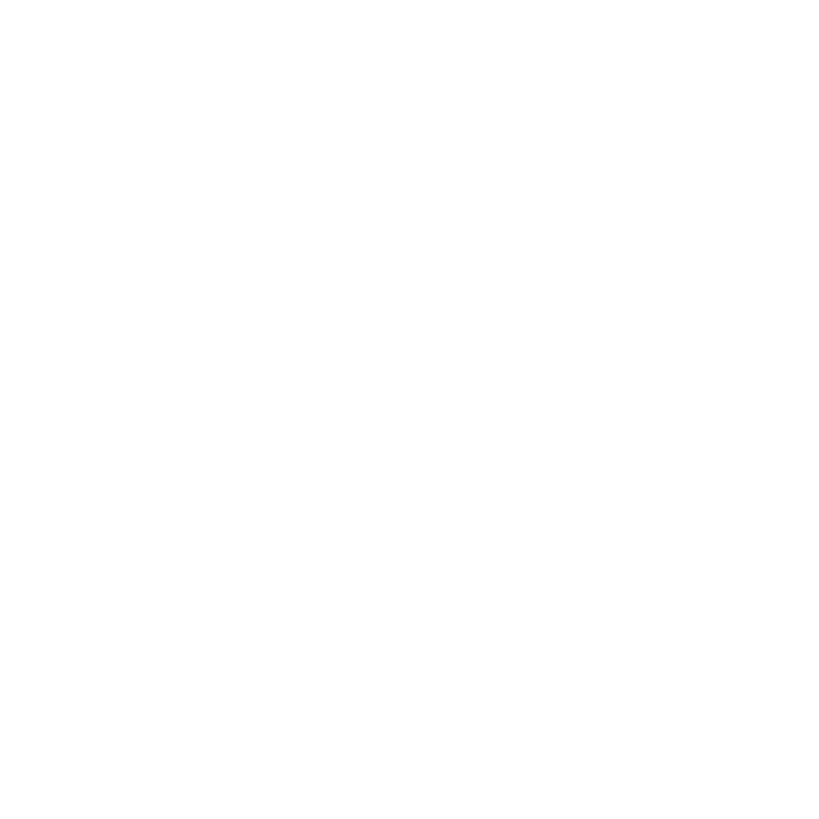

In [18]:
plot_colored_voxels(r_idx_tensors, r_colours)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

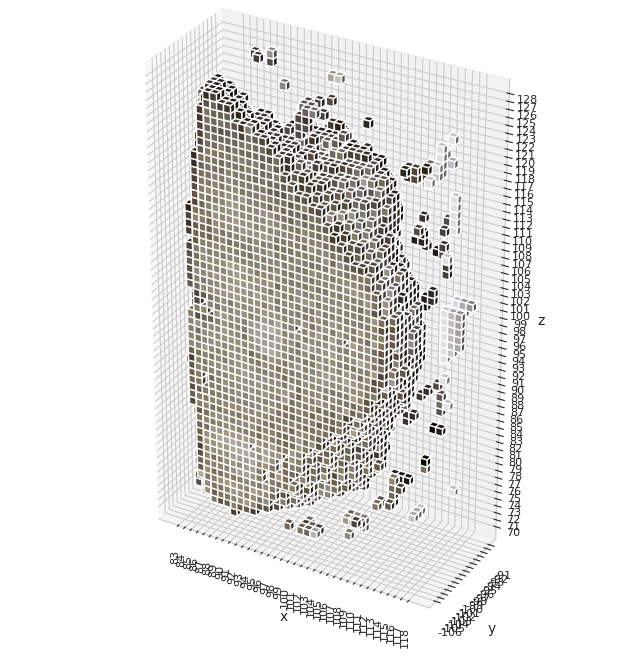

In [19]:
plot_colored_voxels(idx_tensors, r_colours2)


59


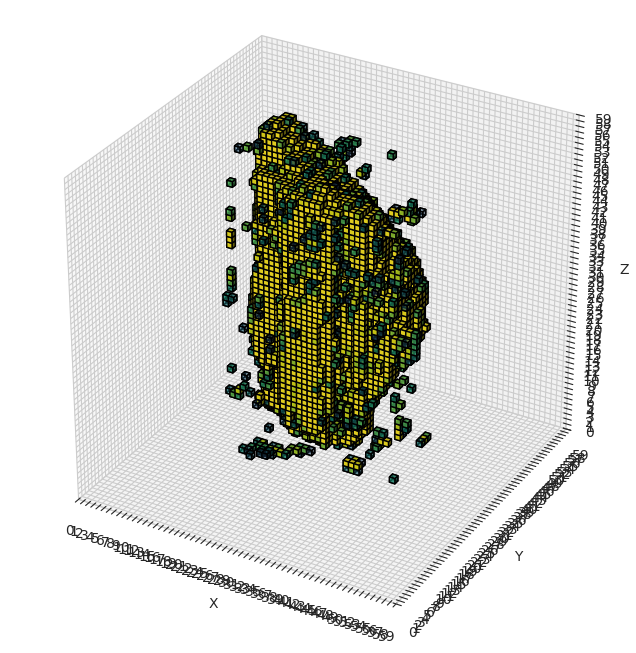

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(71, 130, None), slice(69, 128, None), slice(70, 129, None)))

In [20]:
plot_opacity_tensor(representation[-1], threshold=0.3)

70


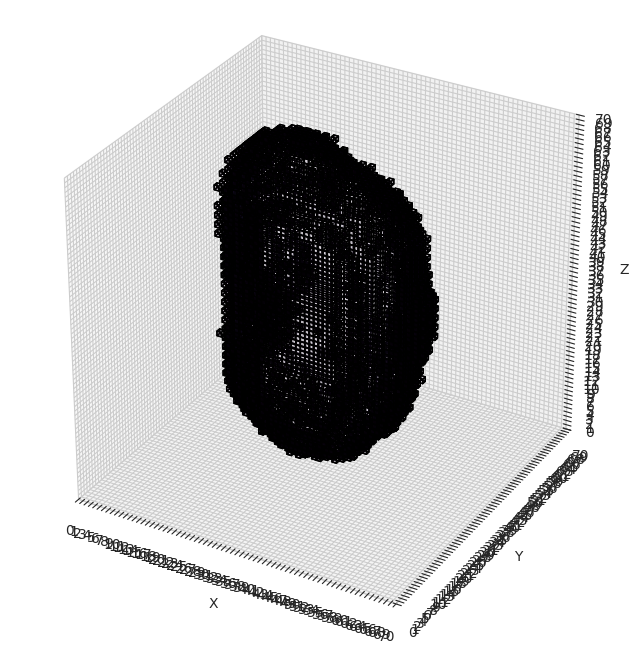

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(66, 136, None), slice(65, 135, None), slice(63, 133, None)))

In [23]:
plot_opacity_tensor(reconstructed_grid[-1], threshold=0.05)


In [21]:
import itertools

In [98]:
axis_swaps = list(itertools.permutations([0, 1, 2]))
axis_flips = [(1, 1, 1)] + list(set(itertools.permutations([1, 1, -1])))
pairs = [list(p) for p in itertools.product(range(len(axis_swaps)), range(len(axis_flips)))]
rotations = [(axis_swaps[a], axis_flips[b]) for a, b in pairs]

In [100]:
axis_swaps

[(0, 1, 2), (0, 2, 1), (1, 0, 2), (1, 2, 0), (2, 0, 1), (2, 1, 0)]

In [99]:
axis_flips

[(1, 1, 1), (1, 1, -1), (1, -1, 1), (-1, 1, 1)]

In [92]:
rotations

[(array([0, 1, 2]), array([1, 1, 1])),
 (array([0, 1, 2]), array([ 1,  1, -1])),
 (array([0, 1, 2]), array([ 1, -1,  1])),
 (array([0, 1, 2]), array([-1,  1,  1])),
 (array([0, 2, 1]), array([1, 1, 1])),
 (array([0, 2, 1]), array([ 1,  1, -1])),
 (array([0, 2, 1]), array([ 1, -1,  1])),
 (array([0, 2, 1]), array([-1,  1,  1])),
 (array([1, 0, 2]), array([1, 1, 1])),
 (array([1, 0, 2]), array([ 1,  1, -1])),
 (array([1, 0, 2]), array([ 1, -1,  1])),
 (array([1, 0, 2]), array([-1,  1,  1])),
 (array([1, 2, 0]), array([1, 1, 1])),
 (array([1, 2, 0]), array([ 1,  1, -1])),
 (array([1, 2, 0]), array([ 1, -1,  1])),
 (array([1, 2, 0]), array([-1,  1,  1])),
 (array([2, 0, 1]), array([1, 1, 1])),
 (array([2, 0, 1]), array([ 1,  1, -1])),
 (array([2, 0, 1]), array([ 1, -1,  1])),
 (array([2, 0, 1]), array([-1,  1,  1])),
 (array([2, 1, 0]), array([1, 1, 1])),
 (array([2, 1, 0]), array([ 1,  1, -1])),
 (array([2, 1, 0]), array([ 1, -1,  1])),
 (array([2, 1, 0]), array([-1,  1,  1]))]

In [93]:
len(rotations)

24

In [95]:
sum((1, -1 ,-1))

-1

In [96]:
def get_rotation_a_to_b(a, b):
    axis_swap_a = a[0]
    axis_swap_b = b[0]
    axis_flip_a = a[1]
    axis_flip_b = b[1]

    axis_swap = np.arange(3)[np.argsort(axis_swap_a)][axis_swap_b]
    axis_flip = axis_flip_a * axis_flip_b
    if np.sum(axis_flip) < -1:
        axis_flip = axis_flip * -1

    return axis_swap, axis_flip

In [97]:
test_a = rotations[7]
test_b = rotations[15]
a_to_b = get_rotation_a_to_b(test_a, test_b)
print(test_b)
print(test_a[0][a_to_b[0]])
print(test_a[1] * a_to_b[1])
a_to_b

(array([1, 2, 0]), array([-1,  1,  1]))
[1 2 0]
[-1  1  1]


(array([2, 1, 0]), array([1, 1, 1]))

In [120]:
def get_normal_category(rotations):
    swaps, flips = zip(*rotations)
    category = torch.zeros(len(rotations), 6)
    swaps = torch.tensor(swaps)

    y_flips = [flip[1] for flip in flips]
    for i, x in enumerate(y_flips):
        if x == 1:
            category[i, :3] = (swaps[i] == 1).float()
        else:
            category[i, -3:] = (swaps[i] == 1).float()

    return category

In [121]:
rotations

[((0, 1, 2), (1, 1, 1)),
 ((0, 1, 2), (1, 1, -1)),
 ((0, 1, 2), (1, -1, 1)),
 ((0, 1, 2), (-1, 1, 1)),
 ((0, 2, 1), (1, 1, 1)),
 ((0, 2, 1), (1, 1, -1)),
 ((0, 2, 1), (1, -1, 1)),
 ((0, 2, 1), (-1, 1, 1)),
 ((1, 0, 2), (1, 1, 1)),
 ((1, 0, 2), (1, 1, -1)),
 ((1, 0, 2), (1, -1, 1)),
 ((1, 0, 2), (-1, 1, 1)),
 ((1, 2, 0), (1, 1, 1)),
 ((1, 2, 0), (1, 1, -1)),
 ((1, 2, 0), (1, -1, 1)),
 ((1, 2, 0), (-1, 1, 1)),
 ((2, 0, 1), (1, 1, 1)),
 ((2, 0, 1), (1, 1, -1)),
 ((2, 0, 1), (1, -1, 1)),
 ((2, 0, 1), (-1, 1, 1)),
 ((2, 1, 0), (1, 1, 1)),
 ((2, 1, 0), (1, 1, -1)),
 ((2, 1, 0), (1, -1, 1)),
 ((2, 1, 0), (-1, 1, 1))]

In [122]:
get_normal_category(rotations)

tensor([[0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0.]])

In [7]:
with torch.no_grad():
    bottleneck_tensor = model.encoder(representation.unsqueeze(0).to(device)).squeeze(0).cpu()

In [8]:
bottleneck_tensor.shape

torch.Size([256, 25, 25, 25])

In [14]:
reconstructed_grid = reconstructed_grid.unsqueeze(0)

In [15]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [16]:
reconstructed_grid_opacity = reconstructed_grid[:, -1:]

In [17]:
reconstructed_grid_opacity.shape

torch.Size([1, 1, 200, 200, 200])

In [20]:
(reconstructed_grid_opacity > 0.5) * 1

tensor([[[[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          ...,

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..

In [20]:
lightning_model.get_dice_loss(representation, reconstructed_grid)

tensor(nan)

In [44]:
representation = representation.unsqueeze(0)
reconstructed_grid = reconstructed_grid.unsqueeze(0)

In [45]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [46]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [47]:
target = lightning_model.categorise_representation(representation)

In [48]:
pred = lightning_model.categorise_representation(reconstructed_grid)

In [49]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [50]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [51]:
(representation[:, -1:] > 0.3).long().shape

torch.Size([1, 1, 200, 200, 200])

In [52]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [53]:
lightning_model.get_dice_loss(reconstructed_grid, representation)


tensor(0.)

In [54]:
pred.shape

torch.Size([1, 1, 200, 200, 200])

In [55]:
pred[:, :, :, :, 0] = 1

In [56]:
lightning_model.dice_loss_score(pred, target)

tensor(0.)

In [59]:
from torchmetrics.segmentation import DiceScore

In [68]:
dice_score = DiceScore(num_classes=2, include_background=False, input_format='index')

In [69]:
dice_score(pred, target)

tensor(0.9936)

In [71]:
dice_score(target, target)

tensor(1.)